# Hafta 15: Makine Öğrenmesi IV: Yapay Sinir Ağları ve Derin Öğrenmeye Giriş — TF Bağlanma Bölgesi Tahmini

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. Yapay nöron, çok katmanlı algılayıcı (MLP), aktivasyon fonksiyonları ve geri yayılımı (backpropagation) elle çözülmüş örnekle anlamak.
2. `scikit-learn` ile MLP eğitmek ve k-mer tabanlı modellerle karşılaştırmak.
3. **1B evrişimli sinir ağının (CNN)** DNA üzerinde bir PWM taraması gibi çalıştığını görmek.
4. PyTorch ile küçük bir CNN eğitmek; öğrenilen filtreleri **motif** olarak yorumlamak ve *in silico* mutajenez yapmak.
5. Dönem projesinin kapsamını ve değerlendirme ölçütlerini netleştirmek.

**Veri:** `tf_baglanma.csv` — 4000 adet 101 bp sentetik dizi; etiket 1 = bir transkripsiyon faktörü (TF) bağlanma motifi içeriyor
(motifin konumu rastgele, bazı negatiflerde motifin karıştırılmış hâli var).

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_tf(klasor="veri"):
    """tf_baglanma.csv: 4000 adet 101 bp dizi; etiket 1 = TF bağlanma bölgesi içeriyor"""
    import os, random, csv
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(99)
    pwm = [  # E-box çekirdekli 10 bp motif (A,C,G,T)
        [0.2, 0.3, 0.3, 0.2], [0.1, 0.6, 0.2, 0.1], [0.05, 0.9, 0.03, 0.02], [0.9, 0.03, 0.05, 0.02],
        [0.03, 0.9, 0.05, 0.02], [0.02, 0.05, 0.9, 0.03], [0.02, 0.03, 0.05, 0.9], [0.03, 0.05, 0.9, 0.02],
        [0.1, 0.2, 0.6, 0.1], [0.2, 0.3, 0.3, 0.2]]
    def motif():
        return "".join(rng.choices("ACGT", weights=w)[0] for w in pwm)
    def rs(n):
        return "".join(rng.choice("ACGT") for _ in range(n))
    satirlar = []
    for i in range(4000):
        s = list(rs(101))
        pozitif = i % 2 == 0
        if pozitif:
            p = rng.randint(0, 91)
            s[p:p + 10] = motif()
            if rng.random() < 0.3:                          # ikinci kopya
                p = rng.randint(0, 91)
                s[p:p + 10] = motif()
        else:
            if rng.random() < 0.35:                         # yanıltıcı: motifin karıştırılmış hali
                m = list(motif()); rng.shuffle(m)
                p = rng.randint(0, 91)
                s[p:p + 10] = m
        satirlar.append((f"tf_{i+1:04d}", "".join(s), int(pozitif)))
    rng.shuffle(satirlar)
    with open(os.path.join(klasor, "tf_baglanma.csv"), "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["id", "dizi", "etiket"])
        w.writerows(satirlar)


if not os.path.exists('veri/tf_baglanma.csv'):
    veri_uret_tf()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'tf_baglanma.csv']


## 1. Yapay nörondan çok katmanlı ağa
Bir nöron: $a = f(w^T x + b)$. Lojistik regresyon, sigmoid aktivasyonlu **tek bir nörondur**.

| Aktivasyon | Formül | Aralık | Kullanım |
|---|---|---|---|
| Sigmoid | $1/(1+e^{-z})$ | (0, 1) | İkili sınıflandırma çıkışı |
| tanh | $(e^z-e^{-z})/(e^z+e^{-z})$ | (−1, 1) | Gizli katman (eski) |
| ReLU | $\max(0, z)$ | [0, ∞) | Gizli katmanlarda varsayılan |
| Softmax | $e^{z_k}/\sum_j e^{z_j}$ | olasılık vektörü | Çok sınıflı çıkış |

**MLP:** Girdi → [Doğrusal + ReLU] × L → Doğrusal + Sigmoid. Gizli katmanlar doğrusal olmayan karar sınırları öğrenmeyi sağlar.
**Eğitim:** Kayıp (ör. ikili çapraz entropi) **zincir kuralı** ile türevlenir (geri yayılım), ağırlıklar gradyan inişiyle güncellenir: $w \leftarrow w - \eta\,\partial\mathcal{L}/\partial w$.

### Sayısal örnek: ileri geçiş + bir geri yayılım adımı
Girdi x = (1, 0) [ör. "motif var", "GC yüksek"], gerçek etiket y = 1.
Gizli katman (2 nöron, ReLU): $W_1 = \begin{pmatrix}0.5 & -0.5\\ 0.3 & 0.8\end{pmatrix}$ (satır: girdi, sütun: nöron), $b_1 = (0, 0.1)$.
Çıkış (sigmoid): $w_2 = (1.0, -1.0)$, $b_2 = 0.2$. Öğrenme hızı η = 0.5.

| Adım | Hesap | Sonuç |
|---|---|---|
| Gizli ön-aktivasyon | $xW_1 + b_1 = (0.5,\ -0.5) + (0, 0.1)$ | (0.5, −0.4) |
| ReLU | max(0, ·) | h = (0.5, 0) |
| Çıkış | $z = 0.5\cdot1.0 + 0\cdot(-1.0) + 0.2$ | z = 0.7 |
| Olasılık | σ(0.7) | p = 0.668 |
| Kayıp | −ln(0.668) | 0.403 |
| Çıkış gradyanı | ∂L/∂z = p − y | −0.332 |
| ∂L/∂w₂ | h · (p − y) | (−0.166, 0) |
| Güncelleme | w₂ − η·∂L/∂w₂ | w₂ = (1.083, −1.0) |

Yeni p: z = 0.5·1.083 + 0.2 = 0.742 → σ = 0.677 (arttı → kayıp azaldı ✔). İkinci gizli nöron ReLU'da "kapalı" (0) olduğundan ağırlığı güncellenmedi.

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, itertools, time
sig = lambda z: 1 / (1 + np.exp(-z))
x = np.array([1.0, 0.0]); y = 1
W1 = np.array([[0.5, -0.5], [0.3, 0.8]]); b1 = np.array([0.0, 0.1])
w2 = np.array([1.0, -1.0]); b2 = 0.2
h = np.maximum(0, x @ W1 + b1); z = h @ w2 + b2; p = sig(z)
print("h =", h, "| z =", round(z, 3), "| p =", round(p, 3), "| kayıp =", round(-np.log(p), 3))
dz = p - y
w2_yeni = w2 - 0.5 * h * dz
print("∂L/∂w2 =", (h * dz).round(3), "| yeni w2 =", w2_yeni.round(3), "| yeni p =", round(sig(h @ w2_yeni + b2), 3))

h = [0.5 0. ] | z = 0.7 | p = 0.668 | kayıp = 0.403
∂L/∂w2 = [-0.166 -0.   ] | yeni w2 = [ 1.083 -1.   ] | yeni p = 0.677


## 2. Veri ve temel (baseline) modeller

In [4]:
veri = pd.read_csv("veri/tf_baglanma.csv")
print(veri.shape, veri.etiket.value_counts().to_dict())
print(veri.dizi.iloc[0])

def kmer_ozellikleri(diziler, k):
    kel = ["".join(p) for p in itertools.product("ACGT", repeat=k)]
    ind = {w: i for i, w in enumerate(kel)}
    X = np.zeros((len(diziler), len(kel)), dtype=np.float32)
    for r, s in enumerate(diziler):
        for i in range(len(s) - k + 1):
            X[r, ind[s[i:i + k]]] += 1
    return X / X.sum(1, keepdims=True), kel

from sklearn.model_selection import train_test_split
idx_egt, idx_test = train_test_split(np.arange(len(veri)), test_size=0.2, stratify=veri.etiket, random_state=0)
idx_egt, idx_dog = train_test_split(idx_egt, test_size=0.125, stratify=veri.etiket.values[idx_egt], random_state=0)   # %70 / %10 / %20
y = veri.etiket.values.astype(np.float32)
print("eğitim/doğrulama/test:", len(idx_egt), len(idx_dog), len(idx_test))

(4000, 3) {0: 2000, 1: 2000}
ATTCGGGACCAGTTAGCCTGCCCGTACAGCTGGCAACTCATCTTCAACACGAACCAAGTTCGGGCACCTCAAAATGGGAGTTCCGACCTTCGCATAGAGAG


eğitim/doğrulama/test: 2800 400 800


In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

sonuc = []
for k in [3, 4, 5]:
    Xk, _ = kmer_ozellikleri(veri.dizi, k)
    for ad, m in [("LR", make_pipeline(StandardScaler(), LogisticRegression(C=0.05, max_iter=3000))),
                  ("MLP (64-16)", make_pipeline(StandardScaler(), MLPClassifier((64, 16), alpha=1e-2, max_iter=300,
                                                                                  early_stopping=True, random_state=0)))]:
        t = time.time(); m.fit(Xk[idx_egt], y[idx_egt])
        p = m.predict_proba(Xk[idx_test])[:, 1]
        sonuc.append({"özellik": f"{k}-mer ({4**k})", "model": ad, "test AUC": roc_auc_score(y[idx_test], p),
                      "test doğruluk": accuracy_score(y[idx_test], p > 0.5), "süre (s)": time.time() - t})
tablo = pd.DataFrame(sonuc).round(3)
tablo

,özellik,model,test AUC,test doğruluk,süre (s)
0,3-mer (64),LR,0.787,0.714,0.015
1,3-mer (64),MLP (64-16),0.778,0.688,0.259
2,4-mer (256),LR,0.848,0.769,0.126
3,4-mer (256),MLP (64-16),0.830,0.759,0.325
4,5-mer (1024),LR,0.827,0.751,0.221
5,5-mer (1024),MLP (64-16),0.812,0.730,0.989


> k-mer frekansları **konum bilgisini** kaybeder ve motifin 10 bazlık bütününü değil yalnızca parçalarını görür. Motifin karıştırılmış
kopyasını içeren negatifler de benzer k-mer bileşimine sahip olduğu için k-mer modelleri zorlanır.

## 3. Evrişim (convolution) = öğrenilebilir PWM taraması
One-hot kodlanmış dizi $X \in \{0,1\}^{L\times4}$ ve uzunluğu *w* olan filtre $F \in \mathbb{R}^{w\times4}$ için:
$$c_i = \sum_{j=1}^{w}\sum_{b\in\{A,C,G,T\}} X_{i+j,b}\,F_{j,b} + \text{bias}$$
Bu, tam olarak **PSSM skoru**dur (5. hafta)! CNN, filtre ağırlıklarını (yani motifleri) veriden **öğrenir**.
Ardından **global maks. havuzlama (max pooling)**: "motif dizinin *herhangi bir yerinde* var mı?" sorusunu yanıtlar → konumdan bağımsızlık.

**Sayısal örnek:** Filtre = `CACGTG` bazları için +1, diğer bazlar için −1 olan 6×4 matris. `TTCACGTGAA` dizisinde:
* konum 2 (`CACGTG`): 6 eşleşme → skor = 6·(+1) = **6** (maksimum)
* konum 0 (`TTCACG`): yalnızca 3. (C) ve 6. (G) bazlar eşleşir → skor = 2 − 4 = **−2**

Maks. havuzlama sonucu 6'dır: motif dizide *bir yerde* var. Kodla doğrulayalım:

In [6]:
def one_hot(s):
    M = np.zeros((len(s), 4), dtype=np.float32)
    for i, b in enumerate(s):
        if b in "ACGT":
            M[i, "ACGT".index(b)] = 1
    return M

motif = "CACGTG"
F = -np.ones((6, 4)); F[np.arange(6), ["ACGT".index(b) for b in motif]] = 1
d = "TTCACGTGAA"
X = one_hot(d)
skorlar = [float((X[i:i + 6] * F).sum()) for i in range(len(d) - 5)]
print("Kaydırmalı skorlar:", skorlar, "-> maks. havuzlama:", max(skorlar), "konum:", int(np.argmax(skorlar)))

from Bio import motifs
from Bio.Seq import Seq
pssm = motifs.create([Seq(motif)]).counts.normalize(pseudocounts=0.1).log_odds()
F_pssm = np.array([[pssm[b][j] for b in "ACGT"] for j in range(6)])
conv = [float((X[i:i + 6] * F_pssm).sum()) for i in range(len(d) - 5)]
print("Evrişim (PSSM filtre):", np.round(conv, 2))
print("Biopython PSSM.calculate:", np.round(pssm.calculate(Seq(d)), 2), "-> aynı ✔")

Kaydırmalı skorlar: [-2.0, -6.0, 6.0, -6.0, -2.0] -> maks. havuzlama: 6.0 konum: 2
Evrişim (PSSM filtre): [ -3.93 -10.84   9.91 -10.84  -3.93]
Biopython PSSM.calculate: [ -3.93 -10.84   9.91 -10.84  -3.93] -> aynı ✔


## 4. PyTorch ile 1B CNN
```
Girdi (4 × 101 one-hot)
  → Conv1d(4→16 filtre, çekirdek=12) → ReLU          # 16 "motif dedektörü"
  → Global maks. havuzlama (her filtre için 1 değer)
  → Dropout(0.3) → Linear(16→1) → Sigmoid             # P(bağlanma)
```
Parametre sayısı: 16·4·12 + 16 (conv) + 16 + 1 (çıkış) = **801** — k-mer + MLP modelinden çok daha az!

In [7]:
try:
    import torch
except ImportError:
    !pip -q install torch
    import torch
import torch.nn as nn
torch.manual_seed(0); np.random.seed(0)
cihaz = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| cihaz:", cihaz)

Xoh = np.stack([one_hot(s).T for s in veri.dizi])          # (N, 4, 101)
def tensor(idx):
    return torch.tensor(Xoh[idx]), torch.tensor(y[idx]).unsqueeze(1)
Xe, ye = tensor(idx_egt); Xd, yd = tensor(idx_dog); Xt, yt = tensor(idx_test)

class DNACNN(nn.Module):
    def __init__(self, n_filtre=16, cekirdek=12):
        super().__init__()
        self.conv = nn.Conv1d(4, n_filtre, cekirdek)
        self.drop = nn.Dropout(0.3)
        self.cikis = nn.Linear(n_filtre, 1)
    def forward(self, x):
        h = torch.relu(self.conv(x))            # (N, filtre, konum)
        h = h.max(dim=2).values                 # global maks. havuzlama
        return self.cikis(self.drop(h))         # logit

model = DNACNN().to(cihaz)
print(model)
print("Parametre sayısı:", sum(p.numel() for p in model.parameters()))

PyTorch 2.14.0+cu130 | cihaz: cpu
DNACNN(
  (conv): Conv1d(4, 16, kernel_size=(12,), stride=(1,))
  (drop): Dropout(p=0.3, inplace=False)
  (cikis): Linear(in_features=16, out_features=1, bias=True)
)
Parametre sayısı: 801


Eğitim süresi: 3.5 s | en iyi doğrulama AUC: 0.930


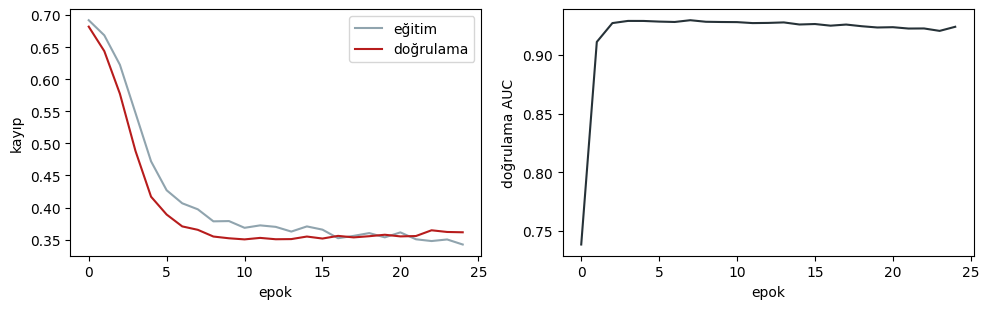

In [8]:
def egit(model, epok=25, lr=3e-3, bs=64):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    kayip_f = nn.BCEWithLogitsLoss()
    gecmis = []
    en_iyi, en_iyi_durum = 0, None
    for ep in range(epok):
        model.train()
        sira = torch.randperm(len(Xe))
        toplam = 0
        for i in range(0, len(Xe), bs):
            b = sira[i:i + bs]
            opt.zero_grad()
            kayip = kayip_f(model(Xe[b].to(cihaz)), ye[b].to(cihaz))
            kayip.backward(); opt.step()
            toplam += kayip.item() * len(b)
        model.eval()
        with torch.no_grad():
            pd_ = torch.sigmoid(model(Xd.to(cihaz))).cpu().numpy().ravel()
            kd = kayip_f(model(Xd.to(cihaz)), yd.to(cihaz)).item()
        auc = roc_auc_score(yd.numpy().ravel(), pd_)
        gecmis.append((toplam / len(Xe), kd, auc))
        if auc > en_iyi:                                  # erken durdurma mantığı: en iyi doğrulama modelini sakla
            en_iyi, en_iyi_durum = auc, {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(en_iyi_durum)
    return np.array(gecmis)

t0 = time.time()
gecmis = egit(model)
print(f"Eğitim süresi: {time.time()-t0:.1f} s | en iyi doğrulama AUC: {gecmis[:, 2].max():.3f}")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(gecmis[:, 0], label="eğitim", color="#90a4ae"); ax[0].plot(gecmis[:, 1], label="doğrulama", color="#b71c1c")
ax[0].set_xlabel("epok"); ax[0].set_ylabel("kayıp"); ax[0].legend()
ax[1].plot(gecmis[:, 2], color="#263238"); ax[1].set_xlabel("epok"); ax[1].set_ylabel("doğrulama AUC")
plt.tight_layout(); plt.show()

In [9]:
model.eval()
with torch.no_grad():
    p_cnn = torch.sigmoid(model(Xt.to(cihaz))).cpu().numpy().ravel()
satir = {"özellik": "one-hot (4×101)", "model": "1B CNN (801 param.)", "test AUC": roc_auc_score(y[idx_test], p_cnn),
         "test doğruluk": accuracy_score(y[idx_test], p_cnn > 0.5), "süre (s)": np.nan}
pd.concat([tablo, pd.DataFrame([satir])]).round(3).reset_index(drop=True)

,özellik,model,test AUC,test doğruluk,süre (s)
0,3-mer (64),LR,0.787,0.714,0.015
1,3-mer (64),MLP (64-16),0.778,0.688,0.259
2,4-mer (256),LR,0.848,0.769,0.126
3,4-mer (256),MLP (64-16),0.830,0.759,0.325
4,5-mer (1024),LR,0.827,0.751,0.221
5,5-mer (1024),MLP (64-16),0.812,0.730,0.989
6,one-hot (4×101),1B CNN (801 param.),0.924,0.848,NaN


## 5. Modeli yorumlamak

### 5.1 Öğrenilen filtreler = motifler
Her filtrenin ağırlık matrisi (4 × 12) bir PWM gibi okunabilir. Çıkış katmanında en büyük pozitif ağırlığa sahip filtreye bakalım.

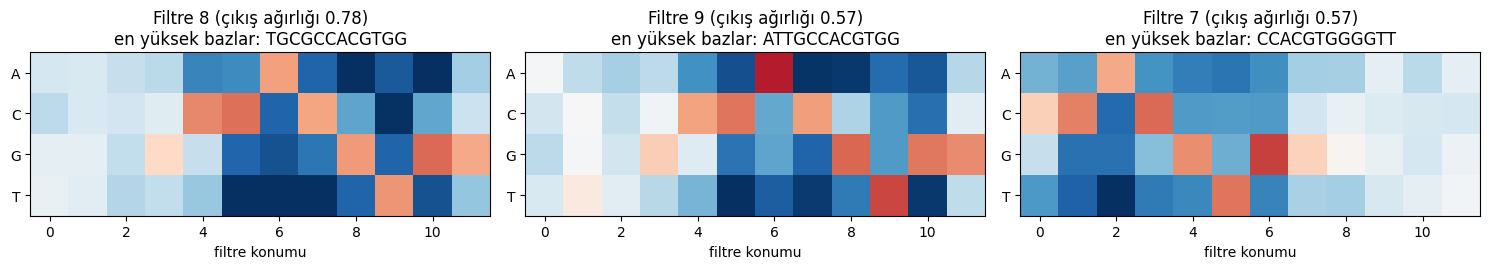

Veri üretiminde kullanılan motifin çekirdeği: CACGTG (E-box), tam motif ≈ NCCACGTGGN


In [10]:
W = model.conv.weight.detach().cpu().numpy()            # (16, 4, 12)
w_cikis = model.cikis.weight.detach().cpu().numpy().ravel()
en_onemli = np.argsort(w_cikis)[::-1][:3]
fig, ax = plt.subplots(1, 3, figsize=(15, 2.8))
for a, f in zip(ax, en_onemli):
    a.imshow(W[f], cmap="RdBu_r", aspect="auto", vmin=-np.abs(W[f]).max(), vmax=np.abs(W[f]).max())
    a.set_yticks(range(4)); a.set_yticklabels(list("ACGT")); a.set_xlabel("filtre konumu")
    konsensus = "".join("ACGT"[i] for i in W[f].argmax(0))
    a.set_title(f"Filtre {f} (çıkış ağırlığı {w_cikis[f]:.2f})\nen yüksek bazlar: {konsensus}")
plt.tight_layout(); plt.show()
print("Veri üretiminde kullanılan motifin çekirdeği: CACGTG (E-box), tam motif ≈ NCCACGTGGN")

### 5.2 *In silico* mutajenez
Pozitif bir dizide her konumdaki bazı sırayla diğer 3 baza çevirip modelin tahminindeki değişimi ölçeriz.
Tahmini en çok düşüren konumlar modelin "önemli" bulduğu bölgedir.

Temel tahmin p = 0.956; en kritik konum 38; çevresindeki dizi: TATCCCACGTGCG


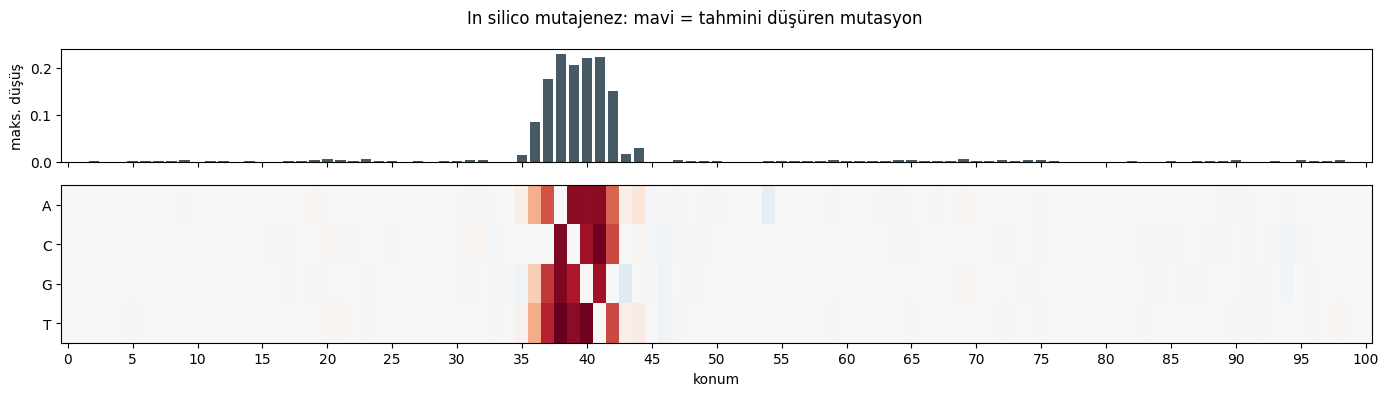

In [11]:
poz = [i for i in idx_test if y[i] == 1 and p_cnn[list(idx_test).index(i)] > 0.9][0]
dizi = veri.dizi.iloc[poz]
temel = one_hot(dizi).T
with torch.no_grad():
    p0 = torch.sigmoid(model(torch.tensor(temel[None]).to(cihaz))).item()
    etki = np.zeros((4, len(dizi)))
    for i in range(len(dizi)):
        for b in range(4):
            mut = temel.copy(); mut[:, i] = 0; mut[b, i] = 1
            etki[b, i] = torch.sigmoid(model(torch.tensor(mut[None]).to(cihaz))).item() - p0
onem = etki.min(0)
bas = int(np.argmin(onem))
print(f"Temel tahmin p = {p0:.3f}; en kritik konum {bas}; çevresindeki dizi: {dizi[max(0, bas-6):bas+7]}")
fig, ax = plt.subplots(2, 1, figsize=(14, 4), sharex=True, gridspec_kw={"height_ratios": [1, 1.4]})
ax[0].bar(range(len(dizi)), -onem, color="#455a64"); ax[0].set_ylabel("maks. düşüş")
ax[1].imshow(etki, cmap="RdBu", aspect="auto", vmin=-np.abs(etki).max(), vmax=np.abs(etki).max())
ax[1].set_yticks(range(4)); ax[1].set_yticklabels(list("ACGT")); ax[1].set_xlabel("konum")
ax[1].set_xticks(range(0, len(dizi), 5))
plt.suptitle("In silico mutajenez: mavi = tahmini düşüren mutasyon"); plt.tight_layout(); plt.show()

## 6. Derin öğrenme biyoinformatikte: kısa bir harita

| Alan | Model | Girdi → Çıktı |
|---|---|---|
| TF bağlanma, kromatin erişilebilirliği | DeepBind, DeepSEA, Basset (CNN) | DNA → bağlanma olasılığı |
| Gen ifadesi tahmini | Enformer (CNN + Transformer) | 200 kb DNA → ifade |
| Protein yapısı | AlphaFold2 (Evoformer) | Dizi + MSA → 3B koordinat |
| Protein dil modelleri | ESM, ProtBERT (Transformer) | Dizi → gömme (embedding) vektörü |
| Varyant etkisi | AlphaMissense, SpliceAI | Mutasyon → patojenite / splicing |

**Uyarılar:** Veri azsa basit modeller çoğu zaman yeterlidir; derin modellerin yorumlanması zordur; homoloji sızıntısı (14. hafta) derin
modellerde de başarıyı şişirir.

## 7. Dönem projesi
Öğrenciler 2–3 kişilik gruplar halinde, bu dönem öğrendikleri araçlarla küçük ama eksiksiz bir biyoinformatik analiz yapar.

**Örnek konular**
1. NCBI'dan bir gen ailesinin dizilerini indirip MSA + filogenetik ağaç kurmak; bootstrap ile yorumlamak.
2. GEO'dan açık bir RNA-seq sayım matrisiyle diferansiyel ifade + kümeleme.
3. UniProt'tan antimikrobiyal / antimikrobiyal olmayan peptitleri indirip sınıflandırıcı kurmak (homoloji sızıntısına dikkat!).
4. Bir TF'nin ChIP-seq tepe dizileriyle (ör. JASPAR/ENCODE) CNN eğitip öğrenilen motifi bilinen motifle karşılaştırmak.
5. Mini-BLAST'ı (8. hafta) protein dizileri ve BLOSUM62 ile genişletip hassasiyet/hız analizi yapmak.
6. PDB'den bir protein ailesi seçip yapısal hizalama (RMSD) ile dizi özdeşliği arasındaki ilişkiyi incelemek.

| Değerlendirme ölçütü | Ağırlık |
|---|---|
| Problem tanımı ve biyolojik motivasyon | %15 |
| Veri toplama, ön işleme ve kalite kontrol | %20 |
| Yöntemlerin doğru uygulanması (sızıntı yok, uygun ölçütler) | %25 |
| Sonuçların görselleştirilmesi ve yorumu | %20 |
| Tekrarlanabilir Colab notebook'u ve kod kalitesi | %10 |
| Sunum (10 dk) | %10 |

## 8. Alıştırmalar
1. Sayısal örnekteki ağda $W_1$'in ilk satırını da güncelleyin (ipucu: ∂L/∂h₁ = (p − y)·w₂₁, ReLU türevi h₁ > 0 için 1).
2. CNN'de filtre sayısını 4, 16, 64 ve çekirdek boyunu 6, 12, 20 alarak doğrulama AUC'sini karşılaştırın.
3. Global **maks.** havuzlama yerine global **ortalama** havuzlama kullanın. Hangisi bu problem için daha uygundur? Neden?
4. **Veri artırma:** Eğitim dizilerinin ters tamamlayıcılarını da eğitim kümesine ekleyin (TF'ler her iki iplikte de bağlanabilir). Test AUC değişti mi?
5. Eğitim kümesinin yalnızca %10'unu kullanarak CNN ve 4-mer LR modelini karşılaştırın. Veri azken hangisi daha iyi?

---
## Çözümler

In [12]:
# 1
dh1 = dz * w2[0]                                   # h1 > 0 -> ReLU türevi 1
W1_yeni = W1.copy(); W1_yeni[:, 0] = W1[:, 0] - 0.5 * x * dh1
print("1) ∂L/∂h1 =", round(dh1, 3), "| W1'in 1. sütunu (1. gizli nöron) ->", W1_yeni[:, 0].round(3))

def hizli_deney(**kw):
    torch.manual_seed(0)
    m = DNACNN(**kw).to(cihaz)
    g = egit(m, epok=12)
    return g[:, 2].max()
# 2 (kısaltılmış ızgara)
for nf, ck in [(4, 12), (16, 6), (16, 20), (64, 12)]:
    print(f"2) filtre={nf:2d} çekirdek={ck:2d} -> doğrulama AUC = {hizli_deney(n_filtre=nf, cekirdek=ck):.3f}")
# 3
class OrtCNN(DNACNN):
    def forward(self, x):
        return self.cikis(self.drop(torch.relu(self.conv(x)).mean(dim=2)))
torch.manual_seed(0); mo = OrtCNN().to(cihaz)
print("3) ortalama havuzlama doğrulama AUC =", round(egit(mo, epok=12)[:, 2].max(), 3), "(motif tek bir yerde -> maks. havuzlama daha uygun)")
# 4
Xe_eski, ye_eski = Xe, ye
Xe = torch.cat([Xe, torch.flip(Xe, dims=[1, 2])]); ye = torch.cat([ye, ye])       # A<->T, C<->G ve ters çevirme
torch.manual_seed(0); m4 = DNACNN().to(cihaz); egit(m4, epok=15); m4.eval()
with torch.no_grad():
    print("4) ters tamamlayıcı artırmalı test AUC =", round(roc_auc_score(y[idx_test], torch.sigmoid(m4(Xt.to(cihaz))).cpu().numpy().ravel()), 3))
Xe, ye = Xe_eski, ye_eski
# 5
kucuk = idx_egt[: len(idx_egt) // 10]
X4, _ = kmer_ozellikleri(veri.dizi, 4)
lr4 = make_pipeline(StandardScaler(), LogisticRegression(C=0.05, max_iter=3000)).fit(X4[kucuk], y[kucuk])
Xe, ye = tensor(kucuk)
torch.manual_seed(0); m5 = DNACNN().to(cihaz); egit(m5, epok=40); m5.eval()
with torch.no_grad():
    auc_cnn = roc_auc_score(y[idx_test], torch.sigmoid(m5(Xt.to(cihaz))).cpu().numpy().ravel())
print(f"5) %10 veri ({len(kucuk)} dizi): 4-mer LR AUC = {roc_auc_score(y[idx_test], lr4.predict_proba(X4[idx_test])[:, 1]):.3f} | CNN AUC = {auc_cnn:.3f}")
Xe, ye = Xe_eski, ye_eski

1) ∂L/∂h1 = -0.332 | W1'in 1. sütunu (1. gizli nöron) -> [0.666 0.3  ]


2) filtre= 4 çekirdek=12 -> doğrulama AUC = 0.912


2) filtre=16 çekirdek= 6 -> doğrulama AUC = 0.907


2) filtre=16 çekirdek=20 -> doğrulama AUC = 0.917


2) filtre=64 çekirdek=12 -> doğrulama AUC = 0.925


3) ortalama havuzlama doğrulama AUC = 0.609 (motif tek bir yerde -> maks. havuzlama daha uygun)


4) ters tamamlayıcı artırmalı test AUC = 0.924


5) %10 veri (280 dizi): 4-mer LR AUC = 0.739 | CNN AUC = 0.870
